# Model evaluation
## Loading the model

In [4]:
import torch
import sys
import os

sys.path.append(os.path.abspath(".."))
from src.model import SimpleCNN

model = SimpleCNN()
model.load_state_dict(torch.load("../models/cnn_cifar10_v1.pth"))
model.eval()

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

## Calculating predictions

In [6]:
import numpy as np
from src.data import get_dataloaders

all_preds = []
all_labels = []

train_dataloader, test_dataloader = get_dataloaders()

model.eval()
with torch.no_grad():
    for images, labels in test_dataloader:
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

C:\Users\micha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## Displaying the confusion matrix
**Strengths of the model:**
- Effectively classifies structural objects (cars, ships)
- High performance on classes with distinct features

**Weaknesses:**
- Confuses visually similar classes (animals)
- Particularly problematic:
  - cat vs. dog
  - deer vs. horse
  - bird vs. other
- Bias towards class 5 (dog)

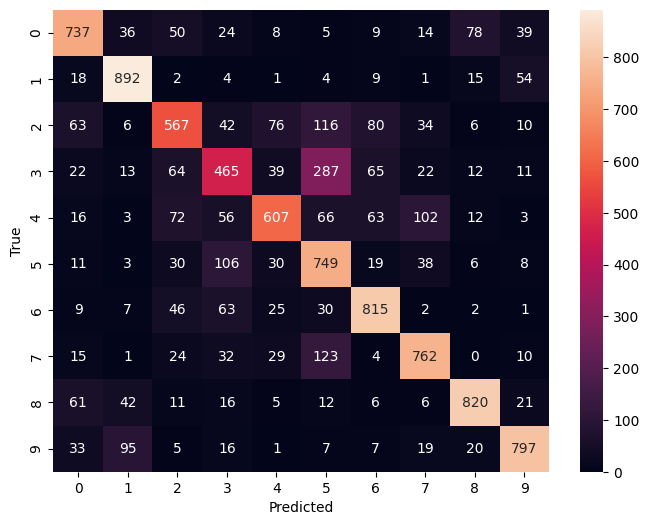

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()